# Model Combination dan Stacking Model

## 1. Import module dan library

In [1]:
import sys
sys.path.append('..')

# Import library yang dibutuhkan
import itertools # Digunakan untuk kombinasi model stacking
import pandas as pd # Digunakan untuk tabel hasil

from sklearn.model_selection import cross_validate, StratifiedKFold
# cross_validate → evaluasi multi-metrik
# StratifiedKFold → membagi data dengan menjaga distribusi label

from sklearn.ensemble import RandomForestClassifier,StackingClassifier
# StackingClassifier → metode ensemble stacking
# RandomForestClassifier → model berbasis tree

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from src import load_objek, simpan_objek

## 2. Alur Logika Code

### 2.1 Load data

In [2]:
data = load_objek ('../data/processed/data_vektor.pkl')

X_train, y_train = data['X_train'], data['y_train']  
# X_train → fitur (vektor TF-IDF)
# y_train → label

X_test, y_test = data['X_test_clean'],data['y_test']
# X_test = digunakan untuk test data


In [3]:
# ============================================================
# MELIHAT DISTRIBUSI LABEL DATA TRAIN & TEST
# ============================================================

import pandas as pd

# ============================================================
# TRAINING DATA
# ============================================================

print("=== DISTRIBUSI DATA TRAIN ===")

train_counts = pd.Series(y_train).value_counts().sort_index()

print(f"Fakta (0) : {train_counts.get(0, 0)}")
print(f"Hoaks (1) : {train_counts.get(1, 0)}")

print(f"Total     : {len(y_train)}")


# ============================================================
# TESTING DATA
# ============================================================

print("\n=== DISTRIBUSI DATA TEST ===")

test_counts = pd.Series(y_test).value_counts().sort_index()

print(f"Fakta (0) : {test_counts.get(0, 0)}")
print(f"Hoaks (1) : {test_counts.get(1, 0)}")

print(f"Total     : {len(y_test)}")

=== DISTRIBUSI DATA TRAIN ===
Fakta (0) : 616
Hoaks (1) : 2433
Total     : 3049

=== DISTRIBUSI DATA TEST ===
Fakta (0) : 154
Hoaks (1) : 609
Total     : 763


### 2.2 Setup base learners

#### 2.2.1 Parameter Default

In [7]:
# ============================================================
# DEFINISI BASE MODELS UNTUK STACKING
# ============================================================

# Dictionary yang berisi kumpulan algoritma dasar (base learners)
# yang akan digunakan pada metode Stacking Ensemble.
#
# Setiap model akan belajar dari data yang sama,
# kemudian hasil prediksinya akan digabungkan
# oleh meta-learner untuk menghasilkan prediksi akhir.

base_models_default = {

    # ========================================================
    # NAIVE BAYES
    # ========================================================

    # Multinomial Naive Bayes cocok digunakan
    # untuk data teks berbasis frekuensi kata
    # seperti hasil TF-IDF.
    #
    # Model ini bekerja berdasarkan probabilitas
    # kemunculan kata pada setiap kelas.

    'NB': MultinomialNB(),


    # ========================================================
    # SUPPORT VECTOR MACHINE (SVM)
    # ========================================================

    # SVM digunakan untuk mencari hyperplane terbaik
    # yang memisahkan antar kelas.
    #
    # Parameter:
    # kernel='rbf'
    # → menggunakan Radial Basis Function,
    #   yaitu kernel default sklearn untuk menangani
    #   data non-linear.
    #
    # probability=False
    # → probabilitas tidak dihitung
    #   untuk mempercepat proses training.

    'SVM': SVC(
        kernel='rbf',      # kernel default sklearn
        probability=False  # probabilitas dimatikan
    ),


    # ========================================================
    # RANDOM FOREST
    # ========================================================

    # Random Forest adalah algoritma ensemble
    # berbasis banyak decision tree.
    #
    # Model bekerja dengan cara:
    # - membangun banyak pohon keputusan
    # - kemudian mengambil voting mayoritas.
    #
    # Parameter:
    # n_estimators=100
    # → menggunakan 100 decision tree.
    #
    # random_state=42
    # → memastikan hasil eksperimen konsisten
    #   ketika kode dijalankan ulang.

    'RF': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),


    # ========================================================
    # LOGISTIC REGRESSION
    # ========================================================

    # Logistic Regression digunakan sebagai model klasifikasi
    # berbasis probabilitas.
    #
    # Walaupun namanya regression,
    # algoritma ini digunakan untuk klasifikasi.
    #
    # max_iter=100
    # → jumlah iterasi maksimum proses optimasi.

    'LR': LogisticRegression(
        max_iter=100
    )
}


# ============================================================
# META LEARNER (LEVEL-1 MODEL)
# ============================================================

# Meta learner adalah model tingkat kedua
# pada arsitektur Stacking Ensemble.
#
# Tugas meta learner:
# - menerima hasil prediksi dari seluruh base models
# - mempelajari pola prediksi terbaik
# - menghasilkan keputusan akhir klasifikasi.
#
# Pada penelitian ini digunakan Logistic Regression
# sebagai meta learner karena:
# - ringan
# - cepat
# - stabil untuk penggabungan output model lain.

meta_learner = LogisticRegression()


# Menampilkan seluruh parameter default
# dari Logistic Regression.
#
# Digunakan untuk:
# - dokumentasi eksperimen
# - memastikan konfigurasi model
# - membantu analisis saat seminar atau laporan.

print(meta_learner.get_params())


# ============================================================
# STRATIFIED K-FOLD CROSS VALIDATION
# ============================================================

# StratifiedKFold digunakan untuk membagi data
# menjadi data training dan validation
# secara bertahap (cross-validation).
#
# "Stratified" berarti proporsi label kelas
# tetap seimbang pada setiap fold.
#
# Cocok digunakan pada dataset klasifikasi,
# terutama jika data bersifat imbalance.

cv = StratifiedKFold(
    n_splits=5,      # data dibagi menjadi 5 fold
    shuffle=True,    # data diacak sebelum dibagi
    random_state=42  # memastikan hasil konsisten
)


# Penjelasan parameter:
#
# n_splits=5
# → proses validasi dilakukan sebanyak 5 kali.
#
# shuffle=True
# → data diacak agar distribusi lebih random.
#
# random_state=42
# → menjaga hasil pembagian data tetap sama
#   setiap kode dijalankan ulang.

{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


### 2.3 Metrik evaluasi dan Eksperimen Kombinasi model

In [8]:
# ============================================================
# IMPORT LIBRARY YANG DIGUNAKAN
# ============================================================

# make_scorer
# → digunakan untuk membuat custom metric scoring
#   pada proses evaluasi model.

# precision_score
# → menghitung ketepatan prediksi positif model.

# recall_score
# → menghitung kemampuan model menemukan
#   seluruh data positif.

# f1_score
# → menghitung keseimbangan antara precision dan recall.

from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score


# cross_validate
# → digunakan untuk melakukan evaluasi model
#   menggunakan cross-validation dengan banyak metrik sekaligus.

from sklearn.model_selection import cross_validate


# StackingClassifier
# → algoritma ensemble stacking dari sklearn.
#   Digunakan untuk menggabungkan beberapa model dasar
#   menjadi satu model yang lebih kuat.

from sklearn.ensemble import StackingClassifier


# itertools
# → digunakan untuk membuat seluruh kombinasi model
#   secara otomatis.

import itertools


# ============================================================
# DEFINISI METRIK EVALUASI
# ============================================================

# Dictionary scoring_metrics digunakan untuk menentukan
# metrik evaluasi yang akan dihitung selama cross-validation.
#
# Pada penelitian ini digunakan 4 metrik utama:
# - Accuracy
# - Precision
# - Recall
# - F1-Score

scoring_metrics = {

    # ========================================================
    # ACCURACY
    # ========================================================

    # Accuracy mengukur seberapa banyak prediksi model
    # yang benar dibandingkan seluruh data.

    'accuracy': 'accuracy',


    # ========================================================
    # PRECISION
    # ========================================================

    # Precision mengukur seberapa tepat prediksi positif model.
    #
    # Rumus:
    # TP / (TP + FP)
    #
    # Cocok digunakan ketika false positive
    # perlu diminimalkan.

    'precision': make_scorer(
        precision_score,
        average='binary',
        zero_division=0
    ),


    # ========================================================
    # RECALL
    # ========================================================

    # Recall mengukur kemampuan model
    # menemukan seluruh data positif.
    #
    # Rumus:
    # TP / (TP + FN)
    #
    # Cocok digunakan ketika false negative
    # harus diminimalkan.

    'recall': make_scorer(
        recall_score,
        average='binary',
        zero_division=0
    ),


    # ========================================================
    # F1-SCORE
    # ========================================================

    # F1-Score adalah rata-rata harmonik
    # antara precision dan recall.
    #
    # Digunakan untuk menilai keseimbangan performa model,
    # terutama pada dataset imbalance.

    'f1': make_scorer(
        f1_score,
        average='binary',
        zero_division=0
    )
}


# ============================================================
# MENYIMPAN HASIL EKSPERIMEN
# ============================================================

# List kosong untuk menyimpan seluruh hasil evaluasi
# dari kombinasi stacking yang diuji.

hasil_eksperimen_default = []


# Menampilkan informasi bahwa proses eksperimen dimulai.

print("Memulai Eksperimen Kombinasi Stacking dengan Metrik Lengkap...\n")


# ============================================================
# MEMBUAT KOMBINASI MODEL
# ============================================================

# range(2, 5)
# berarti:
# - kombinasi 2 model
# - kombinasi 3 model
# - kombinasi 4 model

for r in range(2, 5):

    # Membuat seluruh kombinasi model
    # berdasarkan jumlah r.
    #
    # Contoh:
    # NB + SVM
    # NB + RF
    # SVM + RF + LR
    # dst.

    kombinasi = list(itertools.combinations(base_models_default.items(), r))


    # ========================================================
    # LOOP SETIAP KOMBINASI
    # ========================================================

    for pasang in kombinasi:

        # ====================================================
        # MEMBUAT NAMA KOMBINASI
        # ====================================================

        # Menggabungkan nama model
        # menjadi format string.
        #
        # Contoh:
        # "NB + SVM + RF"

        nama = " + ".join([m[0] for m in pasang])


        # ====================================================
        # CLONE MODEL
        # ====================================================

        # Membuat salinan model baru
        # agar object model tidak digunakan ulang.
        #
        # Tujuannya:
        # Menghindari data leakage atau model overlap
        # antar eksperimen.

        estimators = [
            (
                m[0],
                m[1].__class__(**m[1].get_params())
            )
            for m in pasang
        ]


        # ====================================================
        # MEMBANGUN STACKING CLASSIFIER
        # ====================================================

        # estimators
        # → kumpulan base models.
        #
        # final_estimator
        # → meta learner untuk menggabungkan
        #   hasil prediksi seluruh base model.
        #
        # cv=cv
        # → menggunakan Stratified K-Fold yang sama
        #   agar evaluasi konsisten.
        #
        # n_jobs=-1
        # → menggunakan seluruh core CPU
        #   agar proses lebih cepat.

        stacking_clf = StackingClassifier(
            estimators=estimators,
            final_estimator=meta_learner.__class__(
                **meta_learner.get_params()
            ),
            cv=cv,
            n_jobs=-1
        )


        # ====================================================
        # CROSS VALIDATION
        # ====================================================

        # Melakukan evaluasi model stacking
        # menggunakan cross-validation.
        #
        # Data akan dibagi menjadi beberapa fold,
        # kemudian model dilatih dan diuji
        # secara bergantian.

        scores = cross_validate(
            stacking_clf,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring_metrics,
            n_jobs=-1
        )


        # ====================================================
        # MENGAMBIL NILAI RATA-RATA
        # ====================================================

        # Mengambil rata-rata hasil evaluasi
        # dari seluruh fold cross-validation.

        mean_acc = scores['test_accuracy'].mean()
        mean_prec = scores['test_precision'].mean()
        mean_rec = scores['test_recall'].mean()
        mean_f1 = scores['test_f1'].mean()


        # ====================================================
        # MENYIMPAN HASIL EKSPERIMEN
        # ====================================================

        # Menyimpan hasil evaluasi
        # ke dalam list dictionary.

        hasil_eksperimen_default.append({

            'Kombinasi': nama,
            'Accuracy': mean_acc,
            'Precision': mean_prec,
            'Recall': mean_rec,
            'F1-Score': mean_f1
        })


        # ====================================================
        # MENAMPILKAN HASIL KE TERMINAL
        # ====================================================

        # Menampilkan hasil evaluasi setiap kombinasi model
        # agar mudah dipantau selama eksperimen berjalan.

        print(f"[{nama}]")
        print(f" -> Accuracy  : {mean_acc:.4f}")
        print(f" -> Precision : {mean_prec:.4f}")
        print(f" -> Recall    : {mean_rec:.4f}")
        print(f" -> F1-Score  : {mean_f1:.4f}\n")

Memulai Eksperimen Kombinasi Stacking dengan Metrik Lengkap...

[NB + SVM]
 -> Accuracy  : 0.8308
 -> Precision : 0.8447
 -> Recall    : 0.9655
 -> F1-Score  : 0.9010

[NB + RF]
 -> Accuracy  : 0.8268
 -> Precision : 0.8417
 -> Recall    : 0.9646
 -> F1-Score  : 0.8989

[NB + LR]
 -> Accuracy  : 0.8301
 -> Precision : 0.8383
 -> Recall    : 0.9753
 -> F1-Score  : 0.9016

[SVM + RF]
 -> Accuracy  : 0.8317
 -> Precision : 0.8478
 -> Recall    : 0.9622
 -> F1-Score  : 0.9013

[SVM + LR]
 -> Accuracy  : 0.8308
 -> Precision : 0.8457
 -> Recall    : 0.9638
 -> F1-Score  : 0.9009

[RF + LR]
 -> Accuracy  : 0.8317
 -> Precision : 0.8467
 -> Recall    : 0.9638
 -> F1-Score  : 0.9014

[NB + SVM + RF]
 -> Accuracy  : 0.8324
 -> Precision : 0.8481
 -> Recall    : 0.9626
 -> F1-Score  : 0.9017

[NB + SVM + LR]
 -> Accuracy  : 0.8314
 -> Precision : 0.8461
 -> Recall    : 0.9642
 -> F1-Score  : 0.9013

[NB + RF + LR]
 -> Accuracy  : 0.8311
 -> Precision : 0.8464
 -> Recall    : 0.9634
 -> F1-Score 

### 2.4 Membuat tabel hasil

#### 2.4.1 Parameter Default

In [9]:

df_hasil_default = pd.DataFrame(hasil_eksperimen_default)  
# Mengubah list hasil menjadi DataFrame (tabel)

print("=== RINGKASAN HASIL EKSPERIMEN (DIURUTKAN BERDASARKAN F1-SCORE) ===")

print(
    df_hasil_default
    .sort_values(by='F1-Score', ascending=False)  # Urutkan berdasarkan F1-score tertinggi
    .to_string(index=False)                       # Tampilkan tanpa index
)


=== RINGKASAN HASIL EKSPERIMEN (DIURUTKAN BERDASARKAN F1-SCORE) ===
         Kombinasi  Accuracy  Precision   Recall  F1-Score
     SVM + RF + LR  0.832730   0.848881 0.961771  0.901746
     NB + SVM + RF  0.832401   0.848111 0.962593  0.901664
           NB + LR  0.830108   0.838323 0.975337  0.901595
NB + SVM + RF + LR  0.832073   0.847998 0.962182  0.901433
           RF + LR  0.831746   0.846744 0.963826  0.901424
          SVM + RF  0.831746   0.847752 0.962182  0.901281
     NB + SVM + LR  0.831417   0.846079 0.964236  0.901250
      NB + RF + LR  0.831090   0.846411 0.963415  0.901045
          NB + SVM  0.830760   0.844749 0.965470  0.901017
          SVM + LR  0.830761   0.845727 0.963826  0.900865
           NB + RF  0.826825   0.841666 0.964645  0.898873


### 2.5 Latih model Final

#### 2.5.1 Parameter Default

In [10]:
# ============================================================
# 5. AMBIL KOMBINASI MODEL TERBAIK OTOMATIS
# ============================================================

# Mengurutkan seluruh hasil eksperimen
# berdasarkan nilai F1-Score tertinggi.
#
# ascending=False
# → urutan dari terbesar ke terkecil.
#
# Tujuan:
# Memilih kombinasi model stacking
# dengan performa terbaik.

df_sorted_default = df_hasil_default.sort_values(
    by='F1-Score',
    ascending=False
)


# ============================================================
# AMBIL BARIS TERBAIK
# ============================================================

# Mengambil baris pertama dari hasil sorting.
#
# Karena data sudah diurutkan dari F1 tertinggi,
# maka baris pertama adalah kombinasi terbaik.

best_row = df_sorted_default.iloc[0]


# ============================================================
# AMBIL INFORMASI HASIL TERBAIK
# ============================================================

# Mengambil nama kombinasi model terbaik.
#
# Contoh:
# "NB + SVM + RF"

best_combo = best_row['Kombinasi']


# Mengambil nilai Accuracy terbaik.

best_acc = best_row['Accuracy']


# Mengambil nilai Precision terbaik.

best_prec = best_row['Precision']


# Mengambil nilai Recall terbaik.

best_rec = best_row['Recall']


# Mengambil nilai F1-Score terbaik.

best_f1 = best_row['F1-Score']


# ============================================================
# MENAMPILKAN HASIL MODEL TERBAIK
# ============================================================

# Menampilkan kombinasi model terbaik
# beserta seluruh metrik evaluasinya.

print("\n=== KOMBINASI MODEL TERBAIK ===")
print(f"Kombinasi : {best_combo}")
print(f"Accuracy  : {best_acc:.4f}")
print(f"Precision : {best_prec:.4f}")
print(f"Recall    : {best_rec:.4f}")
print(f"F1-Score  : {best_f1:.4f}")


# ============================================================
# MEMECAH NAMA KOMBINASI MENJADI LIST
# ============================================================

# split(" + ")
# digunakan untuk memisahkan nama model
# menjadi list.
#
# Contoh:
# "NB + SVM"
#
# menjadi:
# ['NB', 'SVM']

best_keys = best_combo.split(" + ")


# ============================================================
# MENGAMBIL MODEL TERBAIK DARI DICTIONARY
# ============================================================

# Mengambil object model asli
# berdasarkan nama model terbaik.
#
# Hasil akhir berupa list estimator
# yang akan digunakan untuk training final.

best_estimators = [
    (key, base_models_default[key])
    for key in best_keys
]


# Menampilkan informasi bahwa proses
# training model final dimulai.

print("\nMelatih Model Final...")


# ============================================================
# MEMBANGUN FINAL STACKING MODEL
# ============================================================

# estimators
# → berisi kombinasi base model terbaik.
#
# final_estimator
# → meta learner yang digunakan
#   untuk menggabungkan prediksi.
#
# n_jobs=-1
# → menggunakan seluruh core CPU
#   agar training lebih cepat.

final_model = StackingClassifier(
    estimators=best_estimators,
    final_estimator=LogisticRegression(),
    n_jobs=-1
)


# ============================================================
# TRAINING MODEL FINAL
# ============================================================

# Melatih model stacking terbaik
# menggunakan seluruh data training.
#
# Setelah tahap ini,
# model siap digunakan untuk:
# - prediksi data testing
# - evaluasi akhir
# - deployment

final_model.fit(X_train, y_train)


=== KOMBINASI MODEL TERBAIK ===
Kombinasi : SVM + RF + LR
Accuracy  : 0.8327
Precision : 0.8489
Recall    : 0.9618
F1-Score  : 0.9017

Melatih Model Final...


,estimators,"[('SVM', ...), ('RF', ...), ...]"
,final_estimator,LogisticRegression()
,cv,None
,stack_method,'auto'
,n_jobs,-1
,passthrough,False
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [11]:
print("\n=== TOP 3 MODEL TERBAIK DEFAULT ===")
print(df_sorted_default.head(3).to_string(index=False))


=== TOP 3 MODEL TERBAIK DEFAULT ===
    Kombinasi  Accuracy  Precision   Recall  F1-Score
SVM + RF + LR  0.832730   0.848881 0.961771  0.901746
NB + SVM + RF  0.832401   0.848111 0.962593  0.901664
      NB + LR  0.830108   0.838323 0.975337  0.901595


#### 2.5.2 Mengambil parameter per model

In [12]:
# ============================================================
# MENAMPILKAN INFORMASI AWAL
# ============================================================

# Menampilkan teks bahwa proses pengambilan
# dan evaluasi masing-masing model akan dimulai.

print("\n=== AMBIL MASING MASING MODEL TERBAIK ===")


# ============================================================
# IMPORT LIBRARY
# ============================================================

# cross_validate
# → digunakan untuk evaluasi model
#   menggunakan cross-validation.

from sklearn.model_selection import cross_validate


# StackingClassifier
# → digunakan untuk membangun model ensemble stacking.

from sklearn.ensemble import StackingClassifier


# pandas
# → digunakan untuk mengelola data tabel
#   seperti DataFrame.

import pandas as pd


# ============================================================
# 1. EVALUASI MODEL TUNGGAL
# ============================================================

# List kosong untuk menyimpan
# hasil evaluasi model tunggal.

hasil_single = []


# Menampilkan informasi bahwa evaluasi
# model tunggal dimulai.

print("=== EVALUASI MODEL TUNGGAL ===\n")


# ============================================================
# LOOP SELURUH MODEL DASAR
# ============================================================

# Melakukan evaluasi satu per satu
# pada seluruh base model.
#
# Contoh:
# - Naive Bayes
# - SVM
# - Random Forest
# - Logistic Regression

for nama, model in base_models_default.items():
    

    # ========================================================
    # CROSS VALIDATION MODEL TUNGGAL
    # ========================================================

    # Melakukan evaluasi model menggunakan
    # Stratified K-Fold Cross Validation.
    #
    # Model dilatih dan diuji beberapa kali
    # agar hasil evaluasi lebih stabil.

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring_metrics,
        n_jobs=-1
    )
    

    # ========================================================
    # MENYIMPAN HASIL EVALUASI
    # ========================================================

    # Mengambil rata-rata hasil evaluasi
    # dari seluruh fold kemudian menyimpannya
    # ke dalam list dictionary.

    hasil_single.append({

        'Model': nama,

        'Accuracy': scores['test_accuracy'].mean(),

        'Precision': scores['test_precision'].mean(),

        'Recall': scores['test_recall'].mean(),

        'F1-Score': scores['test_f1'].mean()
    })
    

    # ========================================================
    # MENAMPILKAN HASIL EVALUASI
    # ========================================================

    # Menampilkan performa masing-masing model tunggal.

    print(f"[{nama}]")

    print(f"Accuracy  : {scores['test_accuracy'].mean():.4f}")

    print(f"Precision : {scores['test_precision'].mean():.4f}")

    print(f"Recall    : {scores['test_recall'].mean():.4f}")

    print(f"F1-Score  : {scores['test_f1'].mean():.4f}\n")


# ============================================================
# MENGUBAH HASIL MENJADI DATAFRAME
# ============================================================

# Mengubah list hasil evaluasi
# menjadi DataFrame agar lebih mudah
# dianalisis dan ditampilkan.

df_single = pd.DataFrame(hasil_single)


# ============================================================
# 2. AMBIL STACKING TERBAIK
# ============================================================

# Menampilkan informasi bahwa evaluasi
# stacking terbaik dimulai.

print("\n=== EVALUASI STACKING TERBAIK ===\n")


# ============================================================
# MEMECAH NAMA KOMBINASI MODEL
# ============================================================

# best_combo berasal dari hasil eksperimen sebelumnya.
#
# Contoh:
# "SVM + RF + LR"
#
# Akan diubah menjadi list:
# ['SVM', 'RF', 'LR']

best_keys = best_combo.split(" + ")


# ============================================================
# MENGAMBIL MODEL TERBAIK
# ============================================================

# Mengambil object model
# berdasarkan kombinasi terbaik.

best_estimators = [
    (key, base_models_default[key])
    for key in best_keys
]


# ============================================================
# MEMBANGUN STACKING MODEL TERBAIK
# ============================================================

# estimators
# → kumpulan model dasar terbaik.
#
# final_estimator
# → meta learner untuk menggabungkan prediksi.
#
# cv=cv
# → menggunakan cross-validation yang sama
#   agar evaluasi konsisten.
#
# n_jobs=-1
# → menggunakan seluruh core CPU.

best_stacking = StackingClassifier(
    estimators=best_estimators,
    final_estimator=meta_learner,
    cv=cv,
    n_jobs=-1
)


# ============================================================
# EVALUASI STACKING MODEL
# ============================================================

# Melakukan cross-validation
# pada stacking model terbaik.

scores_stack = cross_validate(
    best_stacking,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring_metrics,
    n_jobs=-1
)


# ============================================================
# MENYIMPAN HASIL STACKING
# ============================================================

# Menyimpan hasil evaluasi stacking terbaik
# ke dalam dictionary.

hasil_stacking = {

    'Model': f'Stacking ({best_combo})',

    'Accuracy': scores_stack['test_accuracy'].mean(),

    'Precision': scores_stack['test_precision'].mean(),

    'Recall': scores_stack['test_recall'].mean(),

    'F1-Score': scores_stack['test_f1'].mean()
}


# ============================================================
# UBAH HASIL STACKING MENJADI DATAFRAME
# ============================================================

# Mengubah dictionary hasil stacking
# menjadi DataFrame.

df_stacking = pd.DataFrame([hasil_stacking])


# ============================================================
# MENAMPILKAN HASIL STACKING
# ============================================================

# Menampilkan performa stacking model terbaik.

print(f"[Stacking {best_combo}]")

print(f"Accuracy  : {scores_stack['test_accuracy'].mean():.4f}")

print(f"Precision : {scores_stack['test_precision'].mean():.4f}")

print(f"Recall    : {scores_stack['test_recall'].mean():.4f}")

print(f"F1-Score  : {scores_stack['test_f1'].mean():.4f}")


# ============================================================
# 3. GABUNGKAN HASIL MODEL
# ============================================================

# Menggabungkan hasil evaluasi
# model tunggal dan stacking
# menjadi satu tabel.

df_perbandingan = pd.concat(
    [df_single, df_stacking],
    ignore_index=True
)


# ============================================================
# URUTKAN BERDASARKAN F1-SCORE
# ============================================================

# Mengurutkan model berdasarkan
# nilai F1-Score tertinggi.

df_perbandingan = df_perbandingan.sort_values(
    by='F1-Score',
    ascending=False
)


# ============================================================
# MENAMPILKAN HASIL PERBANDINGAN
# ============================================================

# Menampilkan tabel perbandingan
# antara model tunggal dan stacking.

print("\n=== PERBANDINGAN MODEL SINGLE VS STACKING ===")

print(df_perbandingan)


# ============================================================
# 4. SIMPAN HASIL KE FILE CSV
# ============================================================

# Menyimpan hasil perbandingan
# ke file CSV.
#
# Tujuan:
# - dokumentasi penelitian
# - digunakan pada laporan skripsi
# - mempermudah visualisasi lanjutan

df_perbandingan.to_csv(
    "perbandingan_model.csv",
    index=False
)


# Menampilkan informasi bahwa file berhasil disimpan.

print("\nFile disimpan: perbandingan_model.csv")


=== AMBIL MASING MASING MODEL TERBAIK ===
=== EVALUASI MODEL TUNGGAL ===

[NB]
Accuracy  : 0.8114
Precision : 0.8133
Recall    : 0.9914
F1-Score  : 0.8935

[SVM]
Accuracy  : 0.8173
Precision : 0.8189
Recall    : 0.9901
F1-Score  : 0.8964

[RF]
Accuracy  : 0.8147
Precision : 0.8243
Recall    : 0.9757
F1-Score  : 0.8936

[LR]
Accuracy  : 0.8163
Precision : 0.8152
Recall    : 0.9955
F1-Score  : 0.8964


=== EVALUASI STACKING TERBAIK ===

[Stacking SVM + RF + LR]
Accuracy  : 0.8327
Precision : 0.8489
Recall    : 0.9618
F1-Score  : 0.9017

=== PERBANDINGAN MODEL SINGLE VS STACKING ===
                      Model  Accuracy  Precision    Recall  F1-Score
4  Stacking (SVM + RF + LR)  0.832730   0.848881  0.961771  0.901746
1                       SVM  0.817317   0.818890  0.990136  0.896384
3                        LR  0.816333   0.815236  0.995478  0.896378
2                        RF  0.814689   0.824339  0.975740  0.893621
0                        NB  0.811412   0.813256  0.991368  0.89350

#### 2.5.3 Membuat Confusion Matrix Dari Kombinasi Model

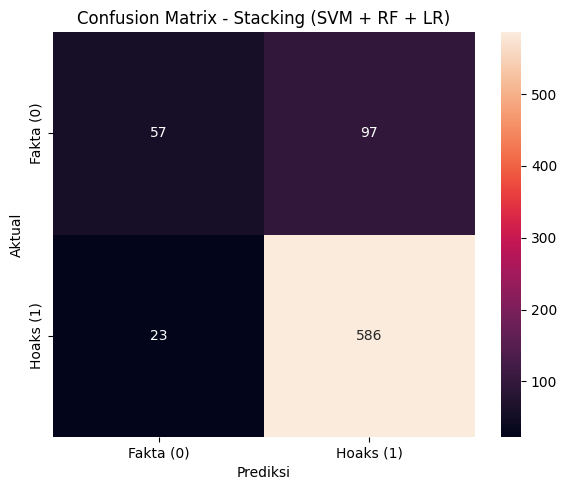

In [13]:
# ============================================================
# CONFUSION MATRIX - MODEL TERBAIK (STACKING)
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 1. TRAIN FINAL MODEL (PAKAI SEMUA DATA TRAIN)
# ============================================================

best_stacking.fit(X_train, y_train)

# ============================================================
# 2. PREDIKSI DATA TEST
# ============================================================

y_pred = best_stacking.predict(X_test)

# ============================================================
# 3. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

labels = ['Fakta (0)', 'Hoaks (1)']

# ============================================================
# 4. VISUALISASI HEATMAP
# ============================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Stacking (SVM + RF + LR)')

plt.tight_layout()
plt.show()

### 2.6 Simpan model

#### 2.6.1 Model Default

In [14]:
simpan_objek(final_model, '../models/stacking_final_default.pkl')  
# Menyimpan model agar bisa digunakan untuk prediksi di masa depan

print("Model final berhasil disimpan!")

Model final berhasil disimpan!


In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# =========================
# TOP 1 MODEL (FIX)
# =========================
estimators = [
    ('svm', SVC()),
    ('rf', RandomForestClassifier(random_state=42)),
    ('lr', LogisticRegression())
]

meta = LogisticRegression()

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=meta,
    cv=cv,
    n_jobs=-1
)

# =========================
# PARAM GRID
# =========================
param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear'],
    'svm__probability': [True],

    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10],

    'lr__C': [0.1, 0.5, 1.0],
    'lr__max_iter': [500, 1000],

    'final_estimator__C': [0.1, 0.5, 1.0],
    'final_estimator__max_iter': [500, 1000]
}

# =========================
# GRID SEARCH
# =========================
grid = GridSearchCV(
    stacking,
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Params :", grid.best_params_)
print("Best Score  :", grid.best_score_)

best_stacking_model = grid.best_estimator_

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


KeyboardInterrupt: 

#### 2.6.3 Melatih Ulang Hasil Tuning

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# ============================================================
# 1. LATIH ULANG MODEL TERBAIK (WAJIB)
# ============================================================
best_stacking_model.fit(X_train, y_train)

# ============================================================
# 2. PREDIKSI KE DATA TEST
# ============================================================
y_pred = best_stacking_model.predict(X_test)

# ============================================================
# 3. HITUNG METRIK EVALUASI
# ============================================================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='binary', zero_division=0)
rec = recall_score(y_test, y_pred, average='binary', zero_division=0)
f1 = f1_score(y_test, y_pred, average='binary', zero_division=0)

# ============================================================
# 4. TAMPILKAN HASIL
# ============================================================
print("=== HASIL PENGUJIAN STACKING (GRID SEARCH) ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")

# ============================================================
# 5. CLASSIFICATION REPORT (OPSIONAL TAPI BAGUS)
# ============================================================
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, zero_division=0))

# ============================================================
# 6. CONFUSION MATRIX (OPSIONAL)
# ============================================================
cm = confusion_matrix(y_test, y_pred)
print("\n=== CONFUSION MATRIX ===")
print(cm)

=== HASIL PENGUJIAN STACKING (GRID SEARCH) ===
Accuracy  : 0.8336
Precision : 0.8523
Recall    : 0.9573
F1-Score  : 0.9018

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.67      0.34      0.45       154
           1       0.85      0.96      0.90       609

    accuracy                           0.83       763
   macro avg       0.76      0.65      0.68       763
weighted avg       0.82      0.83      0.81       763


=== CONFUSION MATRIX ===
[[ 53 101]
 [ 26 583]]


#### 2.6.4 Membandingkan model sebelum tuning vs setelah tuning

Model berhasil di-load!


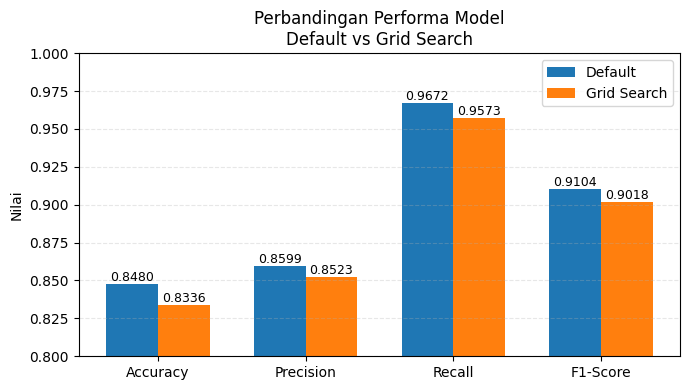

In [ ]:
# ============================================================
# PERBANDINGAN DEFAULT vs GRID SEARCH (LOAD FROM FILE)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pickle
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ============================================================
# 1. LOAD MODEL DARI FOLDER
# ============================================================

with open('../models/stacking_final_default.pkl', 'rb') as f:
    stacking_default_model = pickle.load(f)

with open('../models/stacking_final_tuning.pkl', 'rb') as f:
    best_stacking_model = pickle.load(f)

print("Model berhasil di-load!")

# ============================================================
# 2. PREDIKSI MODEL
# ============================================================

y_pred_default = stacking_default_model.predict(X_test)
y_pred_grid    = best_stacking_model.predict(X_test)

# ============================================================
# 3. HITUNG METRIK
# ============================================================

def get_metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0)
    ]

default_scores = get_metrics(y_test, y_pred_default)
grid_scores    = get_metrics(y_test, y_pred_grid)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# ============================================================
# 4. BAR CHART
# ============================================================

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(7, 4))

bars1 = plt.bar(x - width/2, default_scores, width, label='Default')
bars2 = plt.bar(x + width/2, grid_scores, width, label='Grid Search')

# ============================================================
# 5. LABEL ANGKA
# ============================================================

def add_label(bars):
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.002,
            f'{h:.4f}',
            ha='center',
            fontsize=9
        )

add_label(bars1)
add_label(bars2)

# ============================================================
# 6. TAMPILAN
# ============================================================

plt.xticks(x, metrics)
plt.ylabel('Nilai')
plt.title('Perbandingan Performa Model\nDefault vs Grid Search')

plt.ylim(0.80, 1.00)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("../gambar/perbandingan_model.png", dpi=300, bbox_inches='tight')
plt.show()